<a href="https://colab.research.google.com/github/sarabadrr/lab5/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((256, 256), dtype=np.float32)
img[64:192, 64:192] = 1.0

In [86]:
def MSE(img1,img2):
  return np.mean((img1-img2)**2)

In [87]:
g = np.clip(img + np.random.normal(0, 0.1, img.shape), 0, 1)

mean3 = cv2.blur(g, (3, 3))

geo3 = np.exp(cv2.blur(np.log(g + 1e-6), (3, 3)))

In [88]:
sp = img.copy()
prob = 0.05
mask = np.random.random(img.shape)
sp[mask < prob/2] = 0.0
sp[mask > 1 - prob/2] = 1.0

med3 = cv2.medianBlur((sp * 255).astype(np.uint8), 3) / 255.0

Q = 1.5
num = np.power(sp + 1e-6, Q + 1)
den = np.power(sp + 1e-6, Q)
kernel=np.ones((3,3))
contra = cv2.filter2D(num, -1, np.ones((3,3))) / cv2.filter2D(den, -1, np.ones((3,3)))

In [89]:
print("Gaussian noisy MSE:", MSE(img ,g))
print("Mean filter MSE:", MSE(img ,mean3))
print("Geometric mean MSE:", MSE(img ,geo3))
print("Impulse noisy MSE:", MSE(img ,sp))
print("Median filter MSE:", MSE(img ,med3))

Gaussian noisy MSE: 0.005074220639795026
Mean filter MSE: 0.00386240021789609
Geometric mean MSE: 0.006725837440233352
Impulse noisy MSE: 0.024353027
Median filter MSE: 9.1552734375e-05


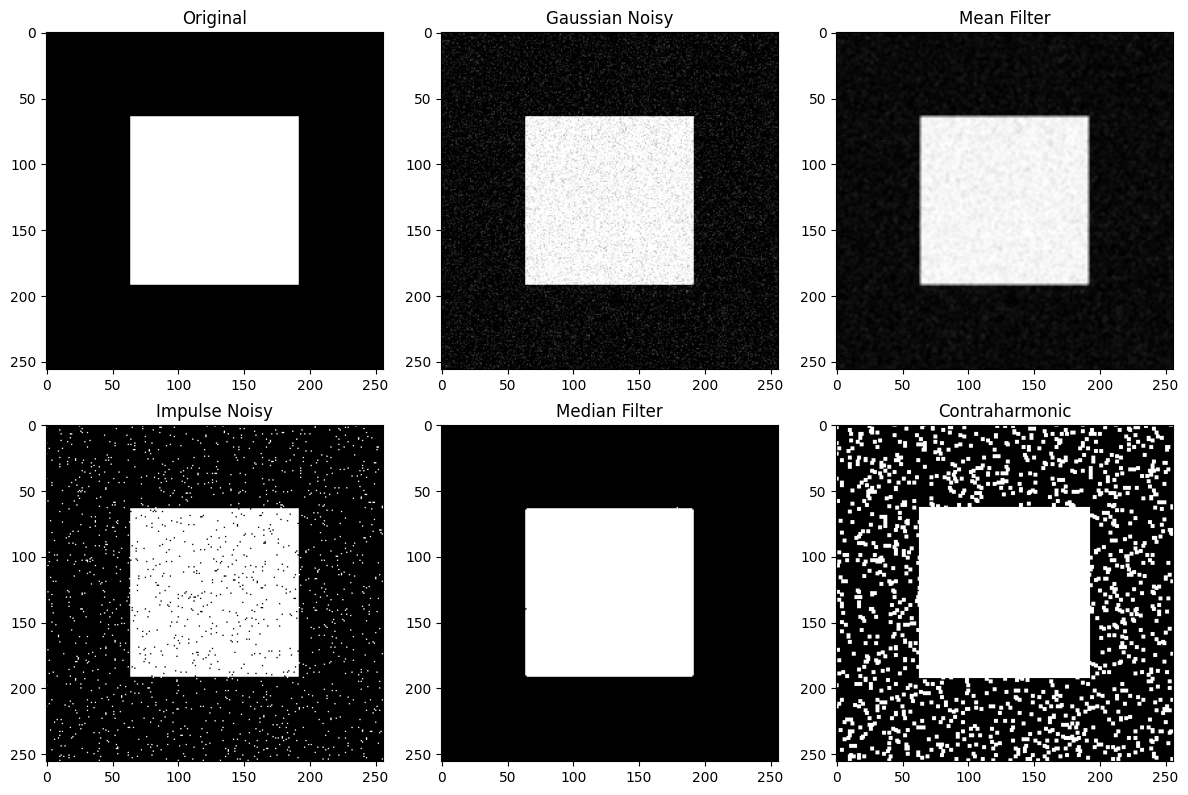

In [90]:
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(img, 'gray'), plt.title('Original')
plt.subplot(232), plt.imshow(g, 'gray'), plt.title('Gaussian Noisy')
plt.subplot(233), plt.imshow(mean3, 'gray'), plt.title('Mean Filter')
plt.subplot(234), plt.imshow(sp, 'gray'), plt.title('Impulse Noisy')
plt.subplot(235), plt.imshow(med3, 'gray'), plt.title('Median Filter')
plt.subplot(236), plt.imshow(contra, 'gray'), plt.title('Contraharmonic')
plt.tight_layout()
plt.show()

Reflection Question

Why is restoration more objective than enhancement?	Restoration uses math to revert an image back to a known original, we can measure success with MSE, enhancement is just making it look better, which depends on human opinion.
Why must noise models be identified first?	Because filters are specific, a mean filter on salt & pepper noise just blurs the dots into gray smudges instead of removing them, u need the right tool for the specific noise.
Why is there no single best denoising filter?	every filter removes some good detail while removing bad noise, the best choice depends on whether you care more about sharpness or cleanliness